<a href="https://colab.research.google.com/github/RFUNN/-/blob/main/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%D0%BB%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

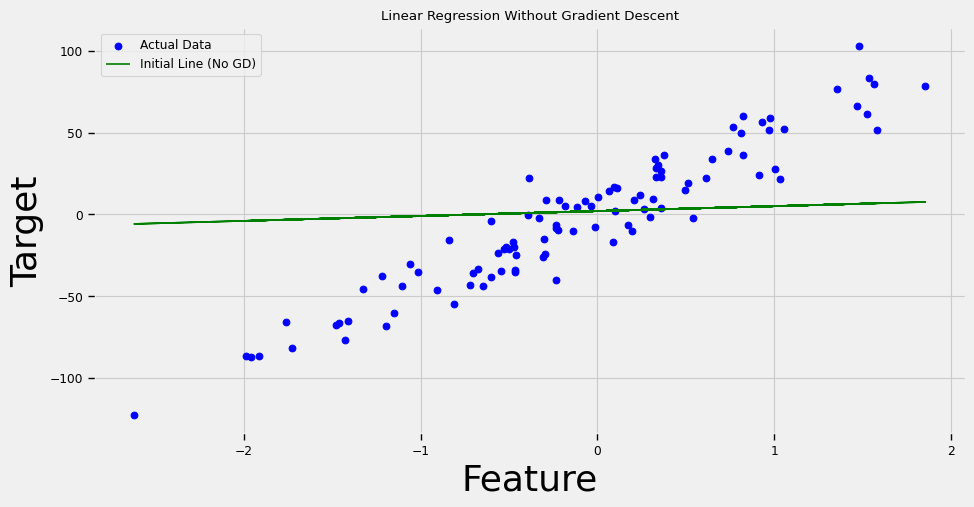

In [231]:
#https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent?hl=ru

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
y = y.reshape(-1, 1)
m = X.shape[0]

X_b = np.c_[np.ones((m, 1)), X]

theta = np.array([[2.0], [3.0]])

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, X_b.dot(theta), color="green", label="Initial Line (No GD)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression Without Gradient Descent")
plt.legend()
plt.show()

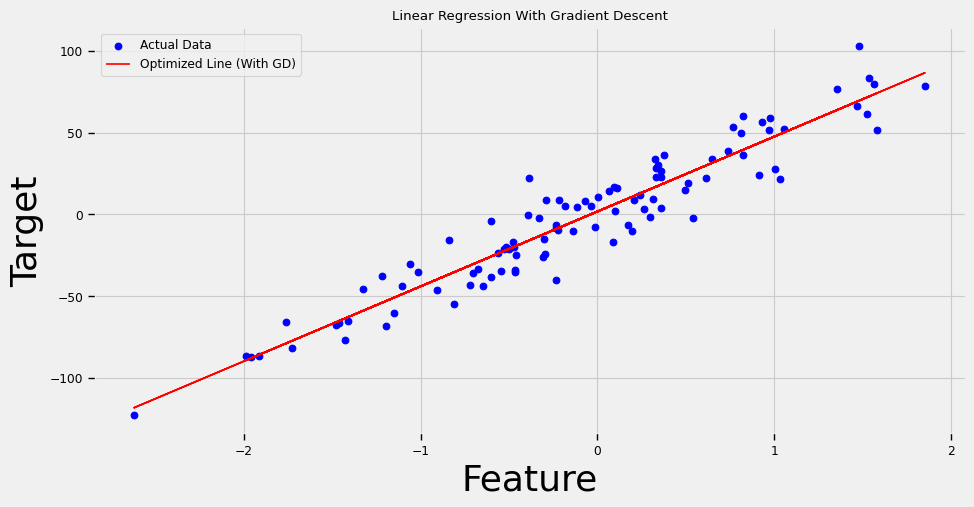

In [232]:
learning_rate = 0.1
n_iterations = 100

for _ in range(n_iterations):

    y_pred = X_b.dot(theta)

    gradients = (2 / m) * X_b.T.dot(y_pred - y)

    theta -= learning_rate * gradients

plt.figure(figsize=(10, 5))
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, X_b.dot(theta), color="red", label="Optimized Line (With GD)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression With Gradient Descent")
plt.legend()
plt.show()

Градиентный спуск — это итеративный алгоритм оптимизации, используемый в машинном и глубоком обучении для поиска параметров модели, минимизирующих заданную функцию стоимости или потерь. В Python он обычно реализуется с использованием библиотек, таких как NumPy, для численных операций.
Основная идея:
Алгоритм работает путем итеративной корректировки параметров модели в направлении, противоположном градиенту функции стоимости. Градиент указывает направление наиболее крутого подъёма, поэтому движение в направлении отрицательного градиента приводит к минимуму функции.
Этапы реализации на Python:

Определение функции стоимости:
Создайте функцию Python, которая вычисляет стоимость (или потерю) на основе прогнозов модели и фактических целевых значений. Например, среднеквадратическая ошибка (MSE) — распространённая функция стоимости для регрессии.
Вычисление градиента:
Определите другую функцию Python для вычисления частных производных функции стоимости по каждому параметру модели. Это и есть градиент. Параметры инициализации:
Начните с начального набора случайных или инициализированных нулем параметров (например, весов и смещений в линейной модели).
Итеративное обновление:
В цикле с заданным количеством итераций (эпох):
Рассчитать градиент функции стоимости при текущих значениях параметров.
Обновить каждый параметр, вычитая скорость обучения, умноженную на соответствующий компонент градиента.
параметр = параметр - скорость_обучения * компонент_градиента
Скорость_обучения:
Скорость_обучения (альфа) — это гиперпараметр, который управляет размером шага каждого обновления. Низкая скорость обучения может привести к медленной сходимости, в то время как большая — к выходу за пределы минимума или расхождению.

In [233]:
import numpy as np

# 1. Define the cost function (e.g., for a simple linear regression)
def cost_function(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/(2*m)) * np.sum(np.square(predictions - y))
    return cost

# 2. Compute the gradient
def compute_gradient(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    gradient = (1/m) * X.T.dot(predictions - y)
    return gradient

# 3. Implement Gradient Descent
def gradient_descent(X, y, theta, learning_rate, num_iterations):
    cost_history = []
    for _ in range(num_iterations):
        gradient = compute_gradient(X, y, theta)
        theta = theta - learning_rate * gradient
        cost_history.append(cost_function(X, y, theta))
    return theta, cost_history

In [234]:
learning_rate = 0.01
num_iterations = 500

In [235]:
theta = np.random.randn(2, 1)

In [236]:
# Perform gradient descent
theta_optimized, cost_history = gradient_descent(X_b, y, theta, learning_rate, num_iterations)

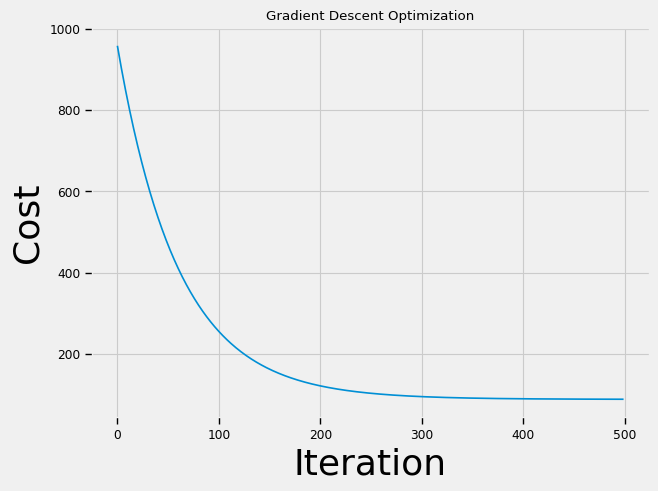

In [237]:
# Plot the cost history over iterations
plt.plot(range(num_iterations), cost_history)
plt.title("Gradient Descent Optimization")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [242]:
print("Intercept:", theta_optimized[0][0])
print("Coefficient:", theta_optimized[1][0])

Intercept: 1.4680616160916062
Coefficient: 44.968466656078135


Text(0.5, 1.0, 'Predicted Profit vs. Population Size')

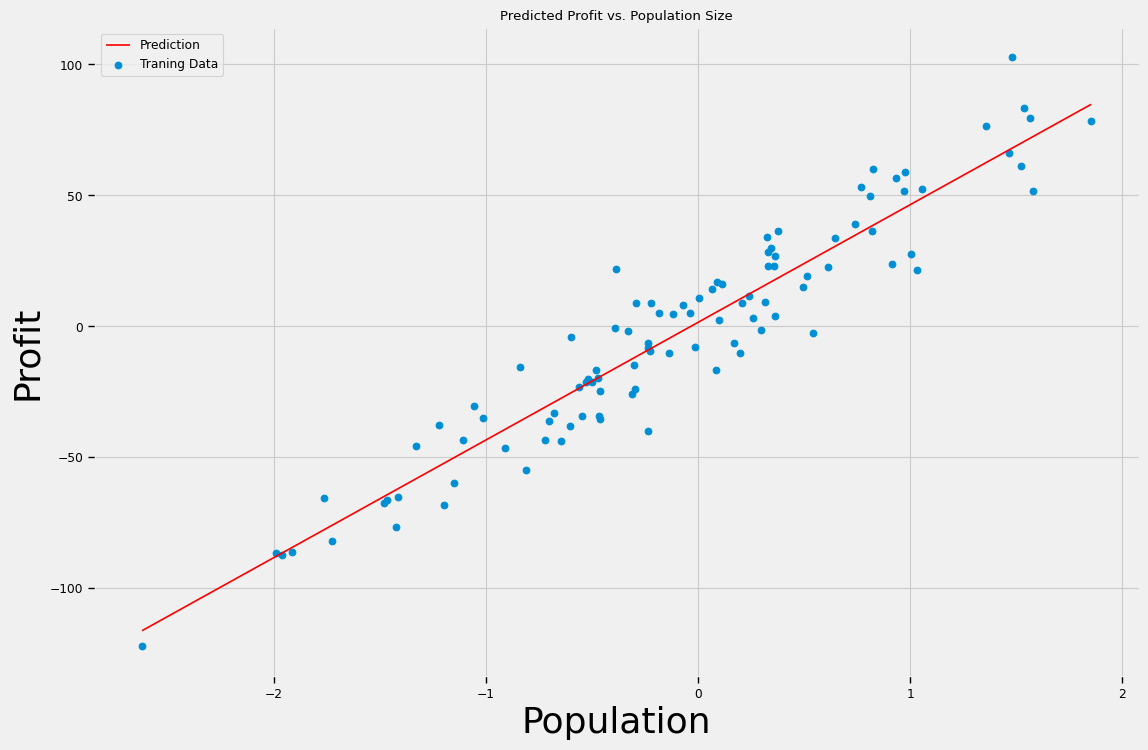

In [247]:
x = np.linspace(X.min(), X.max(),m )
f = theta_optimized[0][0] + (theta_optimized[1][0] * x)

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x, f, 'r', label='Prediction')
ax.scatter(X, y, label='Traning Data')
ax.legend(loc=2)
ax.set_xlabel('Population')
ax.set_ylabel('Profit')
ax.set_title('Predicted Profit vs. Population Size')

In [219]:
# Define gradient descent function for linear regression
def gradient_descent(X, y, learning_rate, n_iterations):
    n = len(y)
    theta = np.array([[0],[0]])  # initialization
    history = np.zeros((n_iterations, 2))  # to store theta values over iterations
    losses = np.zeros(n_iterations)  # to store loss values over iterations

    for iteration in range(n_iterations):
        gradients = 2/n * X.T.dot(X.dot(theta) - y)
        theta = theta - learning_rate * gradients
        history[iteration] = theta.flatten()

        # Calculate loss (Mean Squared Error)
        y_pred = X.dot(theta)
        losses[iteration] = np.mean((y_pred - y) ** 2)

    return theta, history, losses

In [220]:
# Run gradient descent
theta, history, losses = gradient_descent(X_b, y, 0.1, 50)

In [221]:
print("Intercept:", theta[0][0])
print("Coefficient:", theta[1][0])

Intercept: 1.7440169562939252
Coefficient: 45.77708482217793


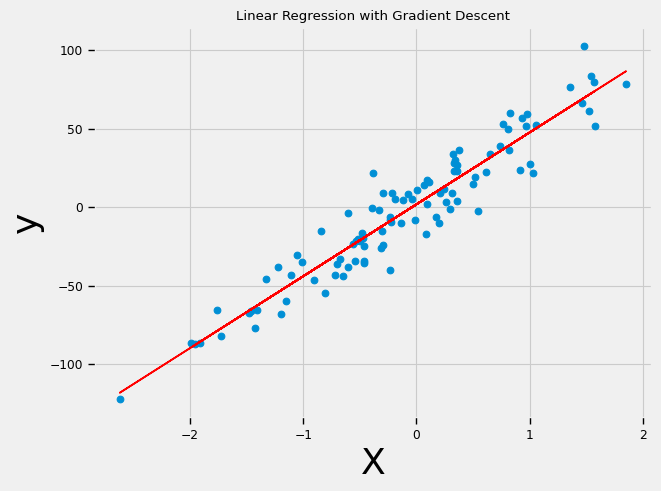

In [222]:
# Plot the data and the linear regression line
plt.scatter(X, y)
plt.plot(X, X_b.dot(theta), color='red')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with Gradient Descent')
plt.show()

Linear regression with one variable

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [187]:
url = 'https://raw.githubusercontent.com/RFUNN/ipython-notebooks/refs/heads/master/data/ex1data1.csv'

data = pd.read_csv(url)

In [188]:
data.describe()

,Population,Profit
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


<Axes: xlabel='Population', ylabel='Profit'>

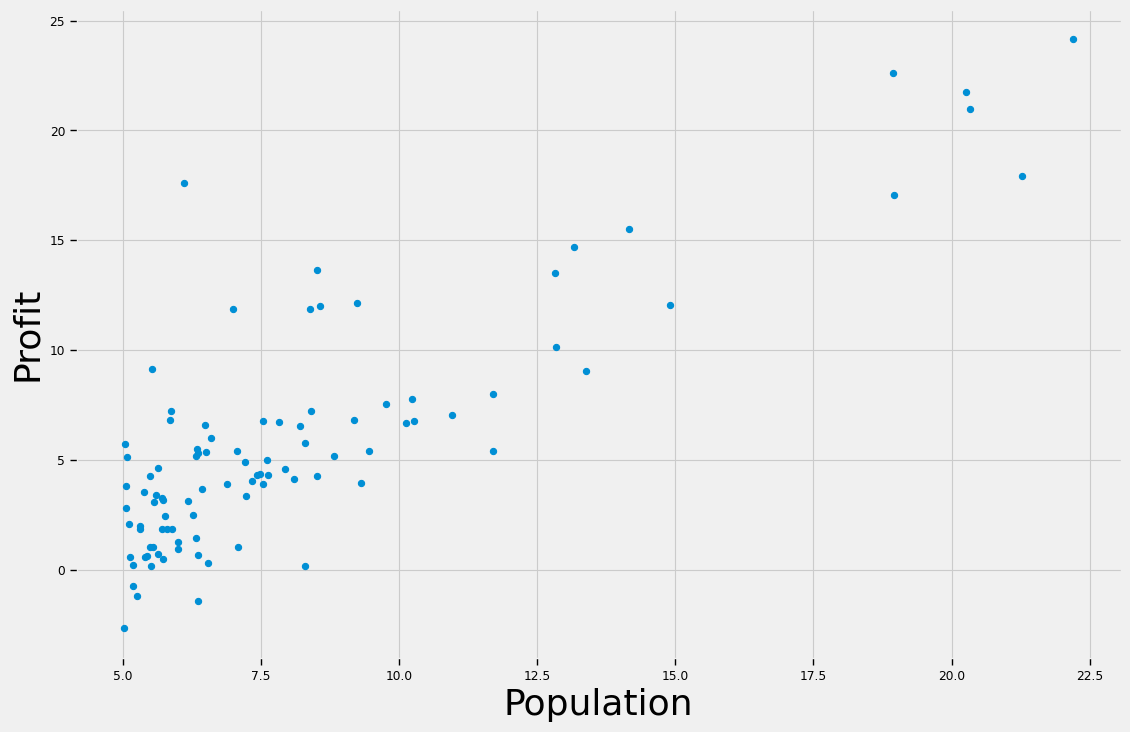

In [189]:
data.plot(kind='scatter', x='Population', y='Profit', figsize=(12,8))



Now let's implement linear regression using gradient descent to minimize the cost function. The equations implemented in the following code samples are detailed in "ex1.pdf" in the "exercises" folder.

First we'll create a function to compute the cost of a given solution (characterized by the parameters theta).


In [190]:
def computeCost(X, y, theta):
    inner = np.power(((X * theta.T) - y), 2)
    return np.sum(inner) / (2 * len(X))

Let's add a column of ones to the training set so we can use a vectorized solution to computing the cost and gradients.

In [191]:
data.insert(0, 'Ones', 1)

Now let's do some variable initialization.

In [192]:
# set X (training data) and y (target variable)
cols = data.shape[1]
X = data.iloc[:,0:cols-1]
y = data.iloc[:,cols-1:cols]

Let's take a look to make sure X (training set) and y (target variable) look correct.

In [193]:
X.head()

,Ones,Population
0,1,6.1101
1,1,5.5277
2,1,8.5186
3,1,7.0032
4,1,5.8598


In [194]:
y.head()

,Profit
0,17.5920
1,9.1302
2,13.6620
3,11.8540
4,6.8233


The cost function is expecting numpy matrices so we need to convert X and y before we can use them. We also need to initialize theta.

In [ ]:
X = np.matrix(X.values)
y = np.matrix(y.values)
theta = np.matrix(np.array([0,0]))

Now let's compute the cost for our initial solution (0 values for theta).

In [196]:
computeCost(X, y, theta)

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
Ones,0.0
Population,0.0
Profit,0.0


In [195]:
def gradientDescent(X, y, theta, alpha, iters):
    temp = np.matrix(np.zeros(theta.shape))
    parameters = int(theta.ravel().shape[1])
    cost = np.zeros(iters)

    for i in range(iters):
        error = (X * theta.T) - y

        for j in range(parameters):
            term = np.multiply(error, X[:,j])
            temp[0,j] = theta[0,j] - ((alpha / len(X)) * np.sum(term))

        theta = temp
        cost[i] = computeCost(X, y, theta)

    return theta, cost

In [ ]:
alpha = 0.01
iters = 1000

In [ ]:
g, cost = gradientDescent(X, y, theta, alpha, iters)
g

In [ ]:
x = np.linspace(data.Population.min(), data.Population.max(), 100)
f = g[0, 0] + (g[0, 1] * x)

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(x, f, 'r', label='Prediction')
ax.scatter(data.Population, data.Profit, label='Traning Data')
ax.legend(loc=2)
ax.set_xlabel('Population')
ax.set_ylabel('Profit')
ax.set_title('Predicted Profit vs. Population Size')

In [ ]:
fig, ax = plt.subplots(figsize=(12,8))
ax.plot(np.arange(iters), cost, 'r')
ax.set_xlabel('Iterations')
ax.set_ylabel('Cost')
ax.set_title('Error vs. Training Epoch')

Linear regression with multiple variables

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


In [120]:
def cost_function(X, y, theta):
    m = y.size
    error = np.dot(X, theta.T) - y
    cost = 1/(2*m) * np.dot(error.T, error)
    return cost, error

In [121]:
def gradient_descent(X, y, theta, alpha, iters):
    cost_array = np.zeros(iters)
    m = y.size
    for i in range(iters):
        cost, error = cost_function(X, y, theta)
        theta = theta - (alpha * (1/m) * np.dot(X.T, error))
        cost_array[i] = cost
    return theta, cost_array


In [122]:
def plotChart(iterations, cost_num):
    fig, ax = plt.subplots()
    ax.plot(np.arange(iterations), cost_num, 'r')
    ax.set_xlabel('Iterations')
    ax.set_ylabel('Cost')
    ax.set_title('Error vs Iterations')
    plt.style.use('fivethirtyeight')
    plt.show()

In [176]:
url = 'https://raw.githubusercontent.com/RFUNN/ipython-notebooks/refs/heads/master/data/ex1data2.csv'

data = pd.read_csv(url)
data.head()

,Size,Bedrooms,Price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


In [177]:
data.describe()

,Size,Bedrooms,Price
count,47.000000,47.000000,47.000000
mean,2000.680851,3.170213,340412.659574
std,794.702354,0.760982,125039.899586
min,852.000000,1.000000,169900.000000
25%,1432.000000,3.000000,249900.000000
50%,1888.000000,3.000000,299900.000000
75%,2269.000000,4.000000,384450.000000
max,4478.000000,5.000000,699900.000000


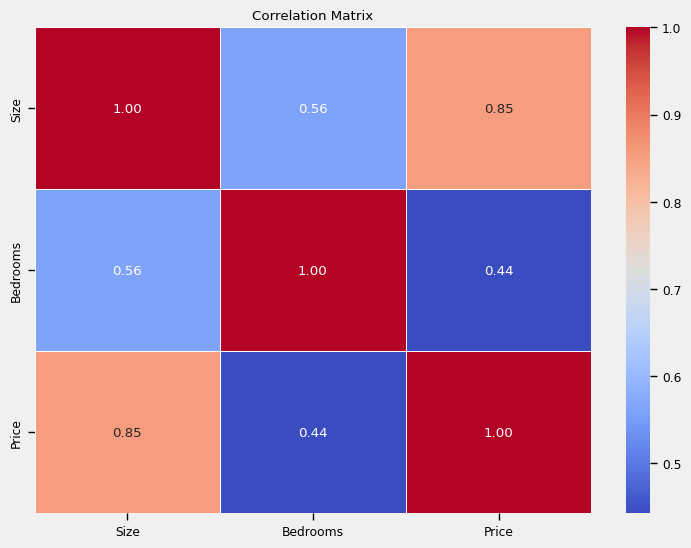

In [178]:
import seaborn as sns
correlation_matrix = data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

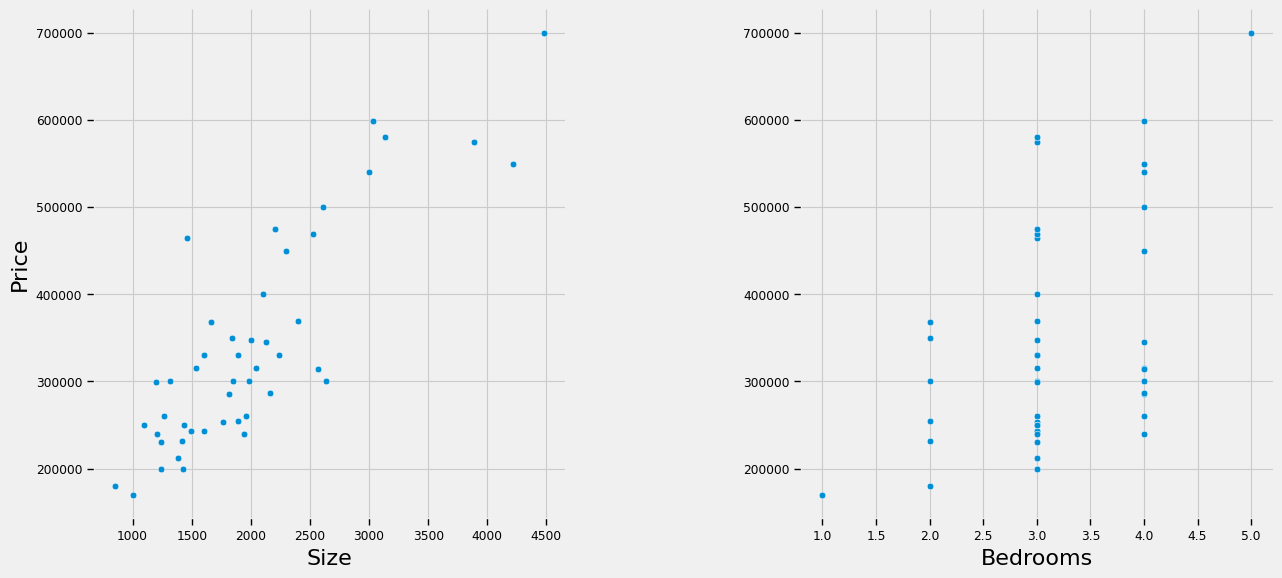

In [149]:
#g = sns.pairplot(data, hue='Price', markers='*')

g=sns.pairplot(
    data,
    x_vars=["Size", "Bedrooms"],
    y_vars=["Price"],
)
for ax in g.axes.flat:
    ax.tick_params(axis='both', labelleft=True, labelbottom=True)

g.fig.set_size_inches(15,7)

plt.subplots_adjust(wspace=0.5, hspace=0.3)

sns.set_context("paper", rc={"axes.labelsize":26})


plt.show()

In [ ]:
unique_values = []
for col in object_cols:
  unique_values.append(dataset[col].unique().size)
plt.figure(figsize=(10,6))
plt.title('No. Unique values of Categorical Features')
plt.xticks(rotation=90)
sns.barplot(x=object_cols,y=unique_values)

In [179]:
data = (data - data.mean()) / data.std()
data.head()

,Size,Bedrooms,Price
0,0.130010,-0.223675,0.475747
1,-0.504190,-0.223675,-0.084074
2,0.502476,-0.223675,0.228626
3,-0.735723,-1.537767,-0.867025
4,1.257476,1.090417,1.595389


In [98]:
correlation_matrix = data.corr()
print(correlation_matrix['Price'])

Size        0.854988
Bedrooms    0.442261
Price       1.000000
Name: Price, dtype: float64


In [99]:
# Extract data into X and y
X = data[['Size', 'Bedrooms']]
y = data['Price']

In [100]:
# Add a 1 column to the start to allow vectorized gradient descent
X = np.c_[np.ones(X.shape[0]), X]

In [101]:
# Set hyperparameters
alpha = 0.01
iterations = 1000

In [102]:
# Initialize Theta Values to 0
theta = np.zeros(X.shape[1])
initial_cost, _ = cost_function(X, y, theta)

print('With initial theta values of {0}, cost error is {1}'.format(theta, initial_cost))


With initial theta values of [0. 0. 0.], cost error is 0.48936170212765956


In [103]:
# Run Gradient Descent
theta, cost_num = gradient_descent(X, y, theta, alpha, iterations)


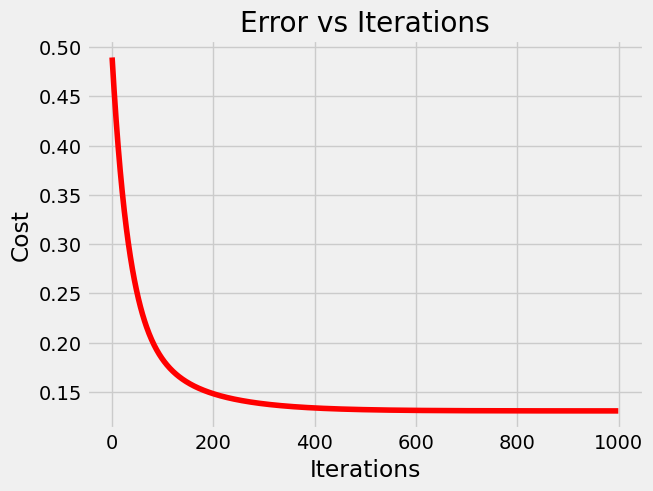

In [104]:
# Display cost chart
plotChart(iterations, cost_num)

In [105]:
final_cost, _ = cost_function(X, y, theta)

print('With final theta values of {0}, cost error is {1}'.format(theta, final_cost))


With final theta values of [-1.10803801e-16  8.78503652e-01 -4.69166570e-02], cost error is 0.13070336960771892


In [106]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)

# The 'LinearRegression' model is initialized and fitted to the training data.
model = LinearRegression()
model.fit(X_train, y_train)

# The model is used to predict the target variable for the test set.
y_pred = model.predict(X_test)


print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))

Mean Squared Error: 0.28700655851686374
R-squared: 0.7047621048745759


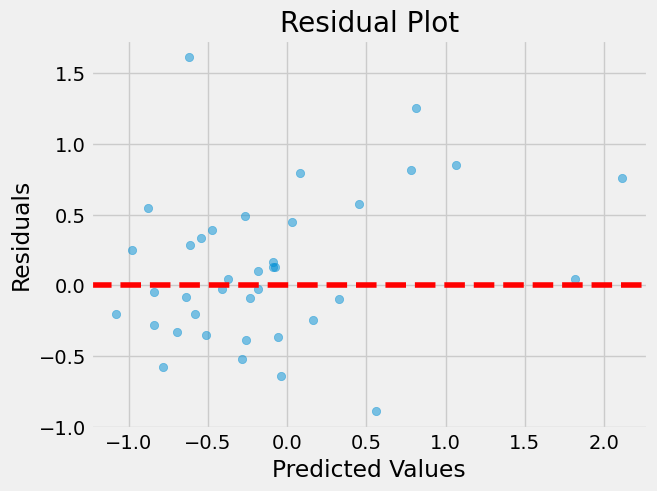

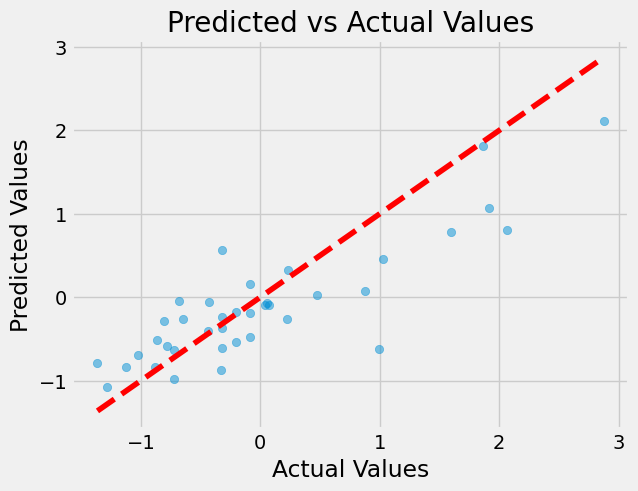

In [107]:
# Residual Plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5)
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.axhline(y=0, color='red', linestyle='--')
plt.show()

# Predicted vs Actual Plot
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Predicted vs Actual Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=4)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.710
Model:                            OLS   Adj. R-squared:                  0.613
Method:                 Least Squares   F-statistic:                     7.348
Date:                Sun, 26 Oct 2025   Prob (F-statistic):             0.0244
Time:                        09:29:04   Log-Likelihood:                -7.2237
No. Observations:                   9   AIC:                             20.45
Df Residuals:                       6   BIC:                             21.04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0991      0.243     -0.409      0.6

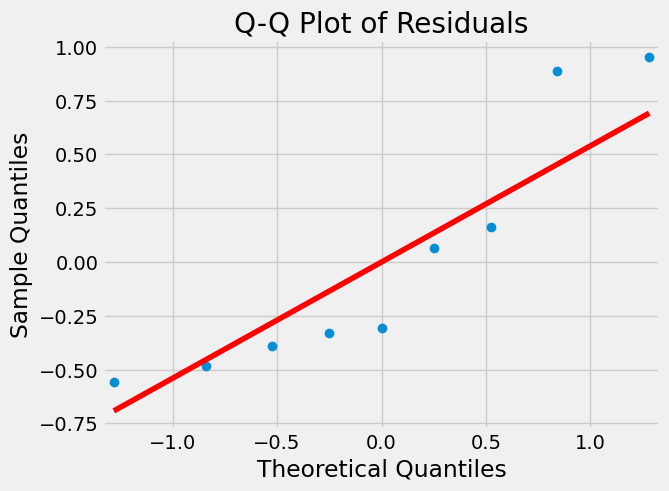

In [118]:
import statsmodels.api as sm

# Add a constant to the model
X_train_sm = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

# Q-Q Plot for residuals
sm.qqplot(model_sm.resid, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

# подробно прочитать https://habr.com/ru/articles/681218/

In [180]:
from sklearn import linear_model
model = linear_model.LinearRegression()
#X = np.asarray(X2)
#y= np.asarray(y2)
model.fit(X, y)
print(model.coef_)

[ 0.          0.88476599 -0.05317882]


In [181]:
y_pred = model.predict(X)

In [182]:
from sklearn.metrics import mean_squared_error
# Calculate Mean Squared Error
mse = mean_squared_error(y, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mse)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print("R-squared:", r2_score(y, y_pred))

Mean Squared Error (MSE): 0.26
Root Mean Squared Error (RMSE): 0.51
R-squared: 0.7329450180289143


Text(0.5, 1.0, 'Predicted Price vs. Size')

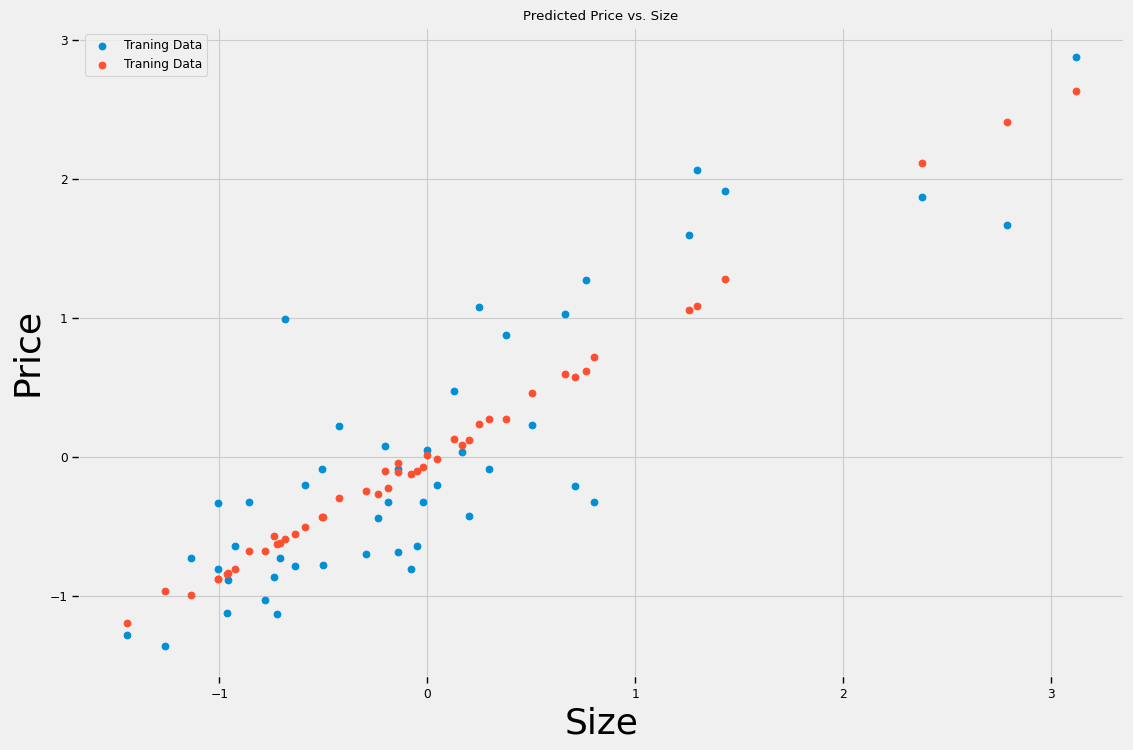

In [184]:


fig, ax = plt.subplots(figsize=(12,8))
#ax.plot(X, f, 'r', label='Price')
ax.scatter(data.Size, data.Price, label='Traning Data')
ax.scatter(data.Size, y_pred, label='Traning Data')
ax.legend(loc=2)
ax.set_xlabel('Size')
ax.set_ylabel('Price')
ax.set_title('Predicted Price vs. Size')